# Project Title: Machine Learning for Supply Chain Optimization.
## Objective: Predictive Demand, Risk Classification, and Inventory Strategy

### Project Submitted by: Sylvester Prasanna
#### version: Date: 15-March-2026


# Phases of the project work
1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Exploratory Data Analysis
5. Modeling
   - Regression
   - Classification
   - Clustering
   - Ensemble
6. Model Comparison, Hyperparameter Tuning, Model Recommendations
7. Conclusion

**********************************
## Step 1: Business Understanding
**********************************

**How can we predict and mitigate the impact of market and seasonal variability on product delivery lead times?**

*This project aims to address fundamental issues in global supply and demand pipelines, which significantly impact macroeconomics and daily life.
It utilizes Machine Learning methodologies to analyze key influencing factors like stockouts, shipping times, and evolving customer needs to improve operational flow and profitability.*

Executive Summary is available in the Readme file.



*****************************
## Step2: Data Understanding
*****************************

- In this section we will import standard Python Libraries, load the dataframe and explore methodologies to understand the data.

The following steps are a part of this section:
-----------------------------------

1. Categorizing the columns (features) to numerical, categorical and not_required (aka dropped columns)
2. Resulting DataFrame is named `df_cleaned`
3. Standardize the date and time for columns Order Date and Shipping Date columns
4. Feature Engineering
5. Data Analysis


In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.vq import kmeans
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")
import plotly.express as px

In [56]:
df = pd.read_csv('data/df_12_months.csv')
df

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/15/2018 11:24,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50102,TRANSFER,3,4,48.439999,254.960007,Advance shipping,0,17,Cleats,Caguas,...,NaN,365,17,NaN,http://images.acmesports.sports/Perfect+Fitnes...,Perfect Fitness Perfect Rip Deck,59.990002,0,5/30/2017 16:48,Standard Class
50103,TRANSFER,3,4,92.110001,248.960007,Advance shipping,0,17,Cleats,Caguas,...,NaN,365,17,NaN,http://images.acmesports.sports/Perfect+Fitnes...,Perfect Fitness Perfect Rip Deck,59.990002,0,5/9/2017 14:34,Standard Class
50104,TRANSFER,4,4,76.989998,245.960007,Shipping on time,0,17,Cleats,Caguas,...,NaN,365,17,NaN,http://images.acmesports.sports/Perfect+Fitnes...,Perfect Fitness Perfect Rip Deck,59.990002,0,4/4/2017 1:18,Standard Class
50105,TRANSFER,3,4,67.489998,224.960007,Advance shipping,0,17,Cleats,Caguas,...,NaN,365,17,NaN,http://images.acmesports.sports/Perfect+Fitnes...,Perfect Fitness Perfect Rip Deck,59.990002,0,5/22/2017 3:51,Standard Class


In [57]:
# Split the columns into Categorical, Numerical and Dropped
categorical_columns = [
    'Type', 'Delivery Status', 'Category Name', 'Customer City', 'Customer Country',
    'Customer Segment', 'Customer State', 'Department Name', 'Market',
    'Order City', 'Order Country', 'Order Region', 'Order State', 'Order Status',
    'Product Name', 'Shipping Mode', 'order date (DateOrders)', 'shipping date (DateOrders)']

numerical_columns = [
    'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order',
    'Sales per customer', 'Late_delivery_risk', 'Latitude', 'Longitude',
    'Customer Zipcode', 'Order Item Discount', 'Order Item Discount Rate',
    'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity',
    'Sales', 'Order Item Total', 'Order Profit Per Order', 'Product Price']

dropped_columns = [
    'Customer Email', 'Customer Password', 'Product Image', 'Product Description',
    'Order Zipcode', 'Customer Fname', 'Customer Lname', 'Customer Street',
    'Customer Id', 'Order Id', 'Order Item Id', 'Product Card Id',
    'Order Customer Id', 'Category Id', 'Department Id', 'Product Category Id',
    'Product Status']

all_cols = set(df.columns)
remaining_cols = all_cols - set(dropped_columns)

categorical_columns = [c for c in categorical_columns if c in remaining_cols]
numerical_columns = [c for c in numerical_columns if c in remaining_cols]

df_cleaned = df.drop(columns=dropped_columns)

df_cleaned.to_csv('df_cleaned.csv', index=False)

df_cleaned['order date (DateOrders)'] = pd.to_datetime(df_cleaned['order date (DateOrders)']).dt.strftime('%Y-%m-%d')
df_cleaned['shipping date (DateOrders)'] = pd.to_datetime(df_cleaned['shipping date (DateOrders)']).dt.strftime('%Y-%m-%d')

df_cleaned.shape

(50107, 36)

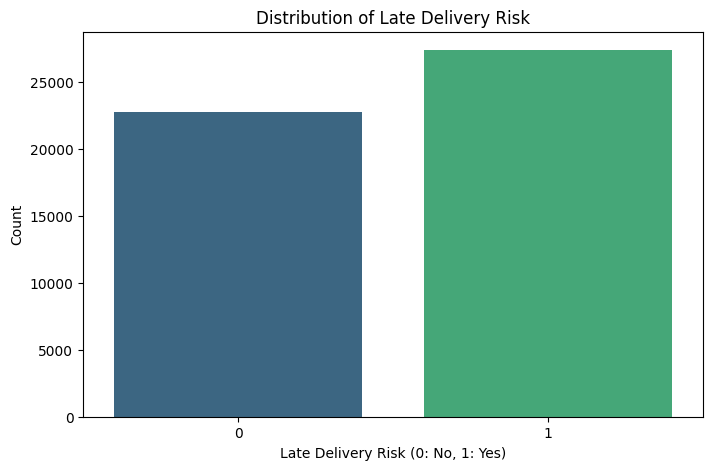

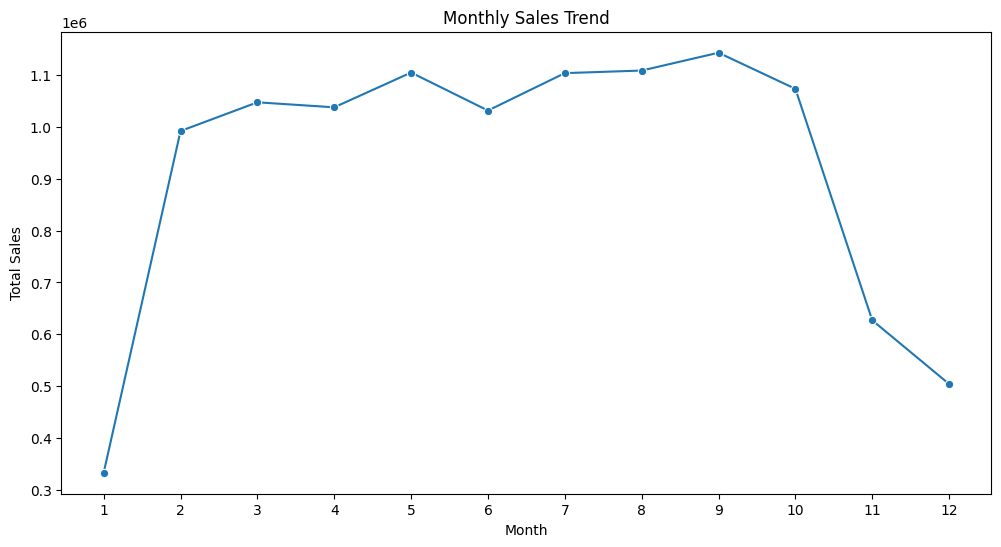

In [58]:
# Feature Engineering
df_cleaned['order date (DateOrders)'] = pd.to_datetime(df_cleaned['order date (DateOrders)'])
df_cleaned['shipping date (DateOrders)'] = pd.to_datetime(df_cleaned['shipping date (DateOrders)'])

# Extracting Year, Month and Day
df_cleaned['order_year'] = df_cleaned['order date (DateOrders)'].dt.year
df_cleaned['order_month'] = df_cleaned['order date (DateOrders)'].dt.month
df_cleaned['order_day'] = df_cleaned['order date (DateOrders)'].dt.day
df_cleaned['order_day_of_week'] = df_cleaned['order date (DateOrders)'].dt.day_name()
df_cleaned['order_hour'] = df_cleaned['order date (DateOrders)'].dt.hour

# Analysis 1: Ontime vs Late Delivery
plt.figure(figsize=(8, 5))
sns.countplot(x='Late_delivery_risk', data=df_cleaned, palette='viridis')
plt.title('Distribution of Late Delivery Risk')
plt.xlabel('Late Delivery Risk (0: No, 1: Yes)')
plt.ylabel('Count')
plt.savefig('images/late_delivery_risk_eda.png')

# Analysis 2: Monthly Sales Trend
plt.figure(figsize=(12, 6))
monthly_sales = df_cleaned.groupby('order_month')['Sales'].sum()
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(range(1, 13))
plt.savefig('images/monthly_sales_trend_eda.png')


In [59]:
# Use_case_1 is to identify correlation of key features.
use_case1 = ['Order Item Quantity', 'Sales', 'Benefit per order', 'Order Item Discount', 'Order Item Total', 'Sales per customer', 'order date (DateOrders)', 'shipping date (DateOrders)']
df_use_case1 = df[use_case1]

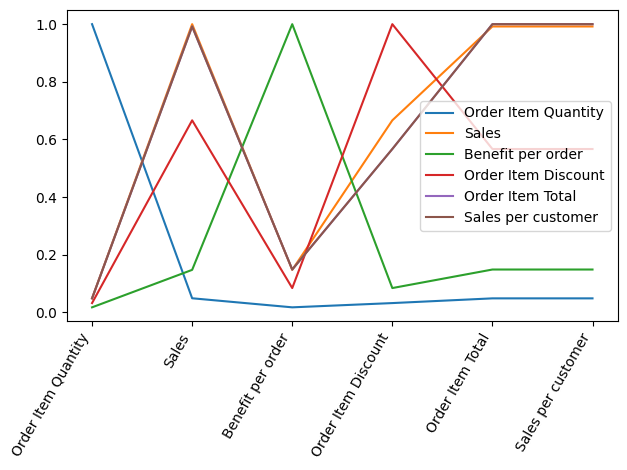

<Figure size 640x480 with 0 Axes>

In [60]:
# Correlation of key features
df_use_case1.select_dtypes(include='number').corr().plot()
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()
plt.savefig('images/Key-features_correlation.png')

In [61]:
## Data Analysis : On time shipment
df_delivery_analysis = df.groupby(['Delivery Status'])['Order Id'].count().reset_index(name='Number of Orders').sort_values(by=['Number of Orders'], ascending=False)
px.bar(x=df_delivery_analysis['Delivery Status'], y=df_delivery_analysis['Number of Orders'], color=df_delivery_analysis['Number of Orders'],)
# plt.savefig('images/On-time-shipment-Plot.png')
# plt.show()


In [62]:
# Top 10 items by sales
data_top_Items = df.groupby(['Category Name'])['Order Id'].count().reset_index(name='Number of Orders').sort_values(
    by='Number of Orders', ascending=True)
px.bar(data_top_Items, x='Number of Orders', y='Category Name', color='Number of Orders')
# plt.savefig('images/Top category items.png')
# plt.show()

*******************************
## Step 3: Data Preparation & Step 4: EDA
*******************************

#### The following steps are a part of this section:

1. Scaling Numerical Columns
2. Using K Means clustering to identify the optimal number of clusters for classification
3. Box Plots to understand features and dependencies.
4. Heat Map
5. One Hot Encoding


In [63]:
# Scaling Numerical Columns

order_date = pd.to_datetime(df_use_case1['order date (DateOrders)'])
shipping_date = pd.to_datetime(df_use_case1['shipping date (DateOrders)'])
df_use_case1['Duration'] = (shipping_date - order_date).dt.days

use_case1_numerical_columns = ['Order Item Quantity', 'Sales', 'Benefit per order', 'Order Item Discount', 'Order Item Total', 'Sales per customer', 'Duration']
scaler = StandardScaler()
df_use_case1_scaled = scaler.fit_transform(df_use_case1[use_case1_numerical_columns])
df_use_case1_scaled = pd.DataFrame(df_use_case1_scaled, columns=use_case1_numerical_columns)
df_use_case1_scaled

,Order Item Quantity,Sales,Benefit per order,Order Item Discount,Order Item Total,Sales per customer,Duration
0,-0.669577,0.608658,0.547381,-0.351578,0.731986,0.731986,-0.278852
1,-0.669577,0.608658,-2.239988,-0.228693,0.711178,0.711178,0.917727
2,-0.669577,0.608658,-2.229259,-0.167250,0.700774,0.700774,0.319437
3,-0.669577,0.608658,-0.012730,0.016703,0.669624,0.669624,-0.278852
4,-0.669577,0.608658,0.899221,0.262473,0.628008,0.628008,-0.877142
...,...,...,...,...,...,...,...
50102,2.213881,0.449027,0.196769,0.842805,0.353375,0.353375,-0.278852
50103,2.213881,0.449027,0.554424,1.067595,0.315311,0.315311,-0.278852
50104,2.213881,0.449027,0.430592,1.179990,0.296279,0.296279,0.319437
50105,2.213881,0.449027,0.352788,1.966754,0.163054,0.163054,-0.278852


[350749.0000000001, 270142.0271855249, 240098.92051572443, 176721.08527057205, 143415.72915124922, 125263.91416099643, 119075.9093116715, 109589.04588340723, 103726.61608911012, 98112.27117642948]


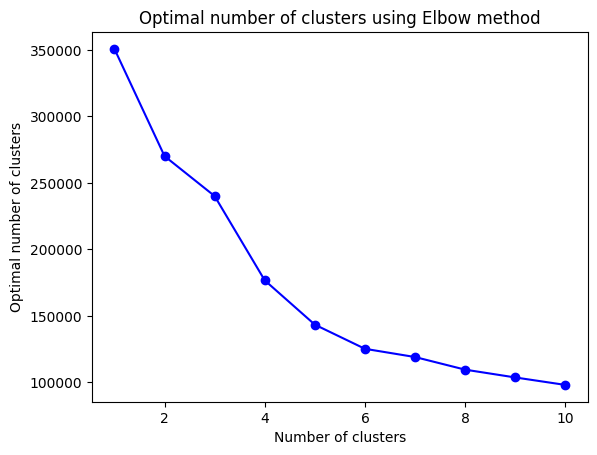

In [64]:
### K-Means Clustering

optimal_cluster = []
for i in range (1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(df_use_case1_scaled)
    optimal_cluster.append(kmeans.inertia_)
print(optimal_cluster)

# Elbow Method to plot for optimal cluster value
plt.plot(range(1,11), optimal_cluster, marker='o', color='blue', label='KMeans')
plt.xlabel('Number of clusters')
plt.ylabel('Optimal number of clusters')
plt.title('Optimal number of clusters using Elbow method')
plt.savefig('images/Optimal Number of Clusters - Elbow method.png')
plt.show()

In [65]:
# Optimal Cluster = 5
optimal_clusters = 5
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42)
df_use_case1['ClusterID'] = kmeans.fit_predict(df_use_case1_scaled)

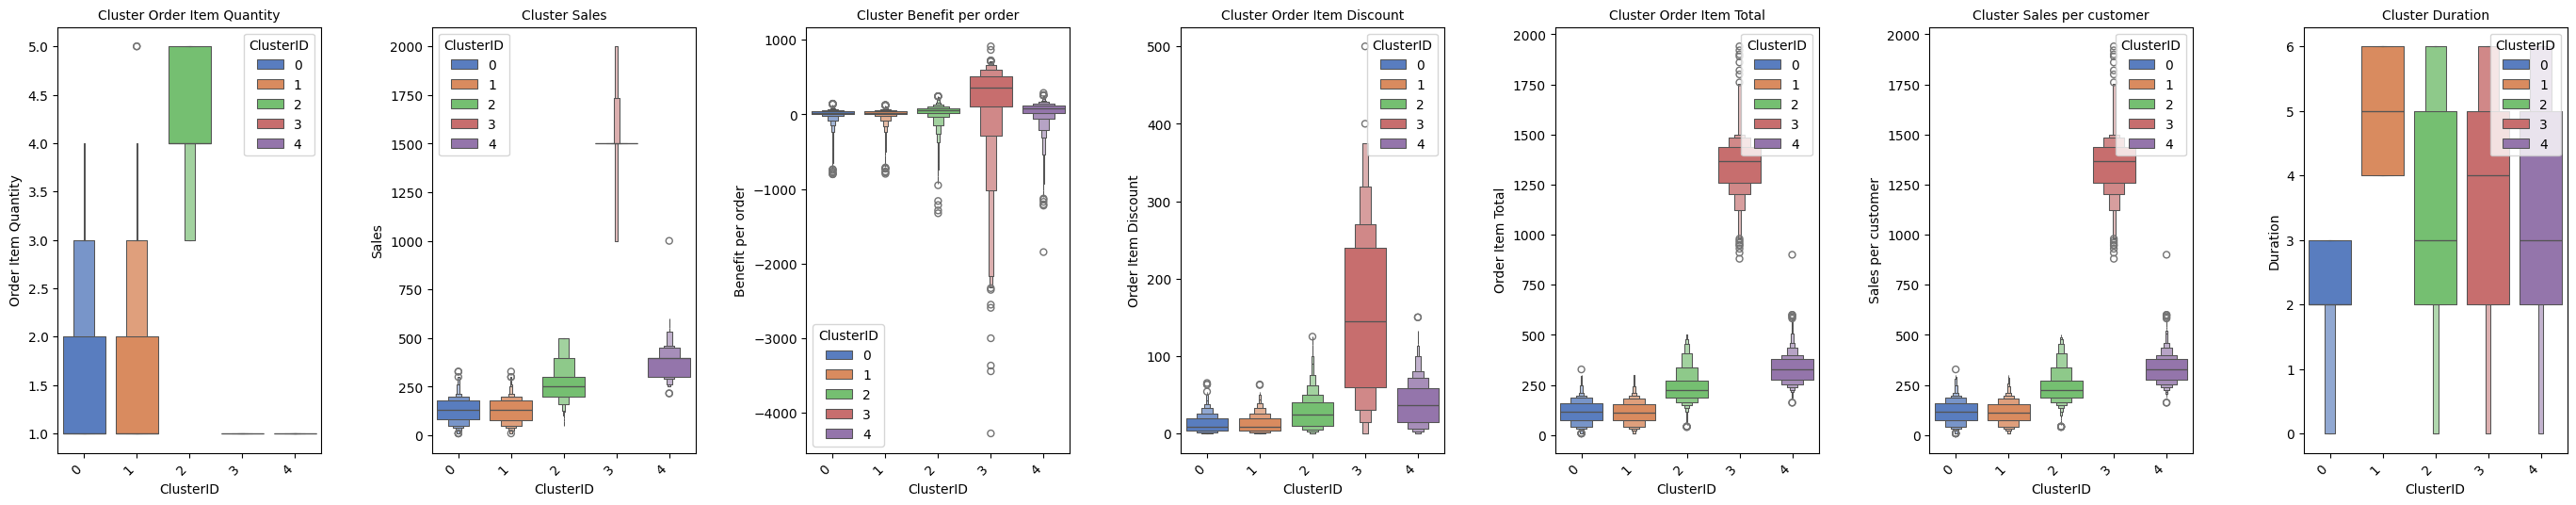

In [66]:
plt.figure(figsize=(28,6))
for i, col in enumerate(use_case1_numerical_columns, 1):
    plt.subplot(1,7,i)
    sns.boxenplot(x='ClusterID', y=col, data=df_use_case1, hue='ClusterID', palette='muted')
    plt.title(f'Cluster {col}', fontsize=10)
    plt.xticks(rotation=45, ha='right')

plt.tight_layout(pad=3.0)
plt.savefig('images/Box-Plot.png')
plt.show()

### Inference from Box Plots

1. *Order Item Quantity*
- Clusters 0, 1, 2 are tightly concentrated around 1–2 units
- Cluster 3 stands out with higher quantities (up to 5), indicating high-volume buyers

2. *Sales*

- Cluster 2 has significantly higher sales with a wide spread (up to ~2000), representing high-value orders
- Clusters 0, 1, 3 are low and tightly packed, suggesting low-value transactions

3. *Benefit per Order*
- Most clusters hover around 0 with some negative outliers, meaning slim or no profit on many orders
- Cluster 1 shows the most negative benefits (down to -4500), indicating heavily loss-making orders — possibly due to high discounts or returns

4. *Order Item Discount*

- Cluster 2 shows the widest spread and highest discounts (up to ~500), suggesting aggressive discounting
- Clusters 0, 1, 3 have low and consistent discounts

5. *Order Item Total*
- Again Cluster 2 dominates with high order totals, consistent with high sales
- Other clusters remain low and concentrated

6. *Sales per Customer*
- Cluster 2 has the highest and most variable sales per customer (up to ~2000), representing your most valuable customers
- Clusters 0, 1, 3 are low-spend customers

7. *Duration (Shipping)*
- Cluster 1 has the longest shipping duration (median ~5 days, up to 6)
- Cluster 0 has the shortest duration (~2–3 days)
- Clusters 2 and 3 fall in between

*Overall Summary*

1. Cluster 2 = High-value, high-sales, high-discount customers — your premium segment
2. Cluster 1 = Loss-making orders with long shipping times — a problematic segment worth investigating
3. Cluster 0 = Low-value, fast-shipping, stable orders — your standard reliable segment
4. Cluster 3 = High quantity but low sales value — possibly bulk buyers of cheap items


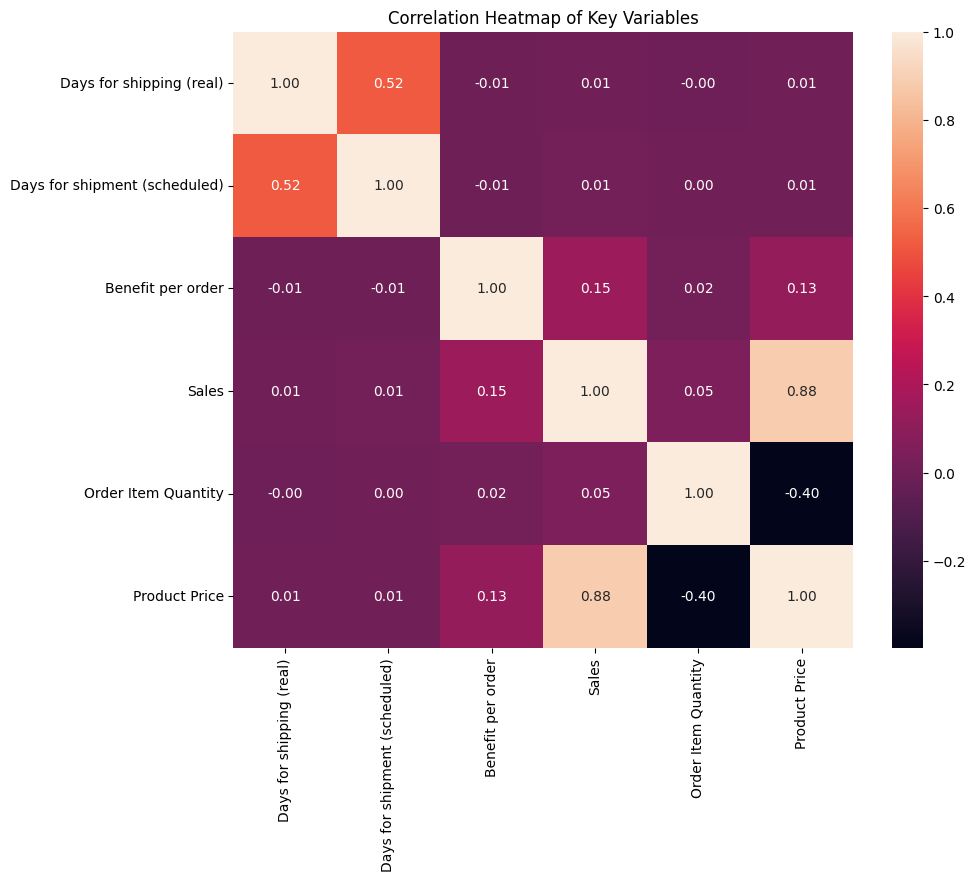

In [67]:
# Plot 3: Correlation Heatmap of key numerical variables
cols_to_drop = ['Order Zipcode', 'Product Description', 'Customer Email', 'Customer Password', 'Product Image',
                'Customer Fname', 'Customer Lname', 'Customer Street']
df_clean = df.drop(columns=cols_to_drop)

key_num_cols = ['Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales', 'Order Item Quantity', 'Product Price']
plt.figure(figsize=(10, 8))
sns.heatmap(df_clean[key_num_cols].corr(), annot=True, fmt=".2f")
plt.title('Correlation Heatmap of Key Variables')
plt.savefig('images/correlation_heatmap.png')


In [68]:
# Data Transformation: One-Hot Encoding
# Selecting   a subset of categorical columns for one-hot encoding to avoid dimensionality explosion, by selecting the most impactful ones.

from sklearn.preprocessing import OneHotEncoder

# 1. Check if Date column is in datetime format
# Replace 'order date (DateOrders)' with the actual date column name
df_cleaned['order date (DateOrders)'] = pd.to_datetime(df_cleaned['order date (DateOrders)'])

# 2. Create the missing 'order_day_of_week' column
df_cleaned['order_day_of_week'] = df_cleaned['order date (DateOrders)'].dt.day_name()

# 3. Run the  existing encoding code
categorical_to_encode = ['Type', 'Customer Segment', 'Market', 'Shipping Mode', 'order_day_of_week']
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_data = encoder.fit_transform(df_cleaned[categorical_to_encode])
encoded_cols = encoder.get_feature_names_out(categorical_to_encode)
df_encoded = pd.DataFrame(encoded_data, columns=encoded_cols)

numerical_cols = [
    'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order',
    'Order Item Discount', 'Order Item Quantity', 'Sales', 'Product Price', 'Late_delivery_risk'
]
df_prepared = pd.concat([df_cleaned[numerical_cols].reset_index(drop=True), df_encoded], axis=1)

df_prepared.to_csv('df_prepared.csv', index=False)

print(f"Prepared dataset shape: {df_prepared.shape}")
print(f"Features created from encoding: {len(encoded_cols)}")
print("Encoded features:", encoded_cols)

Prepared dataset shape: (50107, 29)
Features created from encoding: 21
Encoded features: ['Type_CASH' 'Type_DEBIT' 'Type_PAYMENT' 'Type_TRANSFER'
 'Customer Segment_Consumer' 'Customer Segment_Corporate'
 'Customer Segment_Home Office' 'Market_Europe' 'Market_LATAM'
 'Market_Pacific Asia' 'Shipping Mode_First Class'
 'Shipping Mode_Same Day' 'Shipping Mode_Second Class'
 'Shipping Mode_Standard Class' 'order_day_of_week_Friday'
 'order_day_of_week_Monday' 'order_day_of_week_Saturday'
 'order_day_of_week_Sunday' 'order_day_of_week_Thursday'
 'order_day_of_week_Tuesday' 'order_day_of_week_Wednesday']


********************
## Step 5: Modeling
********************
#### The following steps are a part of this section:


1. Sales Prediction using Linear Regression
2. Shipment delay using Logistic regression and KNN
3. Clustering using K-Means
4. R2 score and Accuracy values.

In [69]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, silhouette_score

# 1. Sales Prediction using Linear Regression
print("\n 1. Sales Prediction using Linear Regression")
X_sales = df_prepared.drop(columns=['Sales'])
y_sales = df_prepared['Sales']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_sales, y_sales, test_size=0.2, random_state=42)

lin_reg = LinearRegression()
lin_reg.fit(X_train_s, y_train_s)
y_pred_s = lin_reg.predict(X_test_s)

print(f"R2 Score: {r2_score(y_test_s, y_pred_s):.4f}")
print(f"Mean Squared Error: {mean_squared_error(y_test_s, y_pred_s):.4f}")
lin_reg.fit(X_train_s, y_train_s)



 1. Sales Prediction using Linear Regression
R2 Score: 0.9646
Mean Squared Error: 1056.3271


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### Inference for predicting the Sales based on a Linear Regression model:
1. R2 Score = 96% (Model is able to successfully capture the variability 96% times, 3% variability remains unexplained). All numerical features (promotions, store) etc are strong influencers for predicting the Sales. Linear and predictable.
2. MSE : Prediction error magnitude of 1056, this equals to an RMSE of appx 32 sales units.
3. Very strong predictive capability, Low prediction error relative to sales magnitude, High explanatory power, selected numerical features are positively influencing the sales pedictions.

In [70]:
# 2. Shipment delay using Logistic Regression
print("\n 2. Shipment Delay Prediction (Classification)")
X_delay = df_prepared.drop(columns=['Late_delivery_risk'])
y_delay = df_prepared['Late_delivery_risk']

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_delay, y_delay, test_size=0.2, random_state=42)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_d, y_train_d)
y_pred_log = log_reg.predict(X_test_d)

print("\nLogistic Regression Evaluation:")
print(f"Accuracy: {accuracy_score(y_test_d, y_pred_log):.4f}")
print(classification_report(y_test_d, y_pred_log))
log_reg.fit(X_train_d, y_train_d)



 2. Shipment Delay Prediction (Classification)

Logistic Regression Evaluation:
Accuracy: 0.9630
              precision    recall  f1-score   support

           0       0.98      0.94      0.96      4620
           1       0.95      0.99      0.97      5402

    accuracy                           0.96     10022
   macro avg       0.97      0.96      0.96     10022
weighted avg       0.96      0.96      0.96     10022



,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

#### Inference for predicting the Shipment delays based on a Logistic Regression model:
( 0 = No shipping delays, 1 = Expect delays (Risk))

1. Very high predictive performance score of 96%, predicts accurately the shipment is delayed / not.
2. Class 0 (No delay), Class 1 (delayed shipment).
   * 2a. Precision (predicting delay, accuracy) : 98% non delays and 95% delays were accurately predicted.
   * 2b. Recall(number of actual delays): 94% and 99%
   * 2c. F1 score (balance between precision and recall): Balanced performance
3. Dataset is fairly balanced, hence both macro avg and weighted avg are at higher %.

#### Result:
* This Logistic Regression model successfully predicts shipment delay risk using the shipment features.
* The model achieved 96.3% overall accuracy, indicating strong predictive capability.
* Recall for delayed shipments is 99%, meaning almost all delay risks are detected.
* Precision and F1 scores above 0.95 indicating a well-balanced classifier.
* This model can support proactive supply chain management, helping companies identify and mitigate shipment delays before they impact customers.
* It can be used to flag high-risk shipments.

In [71]:
# KNN ( Clasification Model for Predicting Shipment Delay Risk)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_d, y_train_d)
y_pred_knn = knn.predict(X_test_d)

print("\nKNN Evaluation:")
print(f"Accuracy: {accuracy_score(y_test_d, y_pred_knn):.4f}")



KNN Evaluation:
Accuracy: 0.6802


In [72]:
# Initializing Pipelines for Model training.
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression

X_delay = df_prepared.drop(columns=['Late_delivery_risk'])
y_delay = df_prepared['Late_delivery_risk']

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_delay, y_delay, test_size=0.2, random_state=42)

# Preprocessing
numeric_features = X_train_d.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train_d.select_dtypes(include=['object']).columns

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combining the preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Creating a unified pipelines for each model
pipeline_lin_reg = Pipeline(steps=[('preprocessor', preprocessor),
                                  ('regressor', lin_reg)])

pipeline_knn = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', knn)])

# Fit the pipelines
pipeline_lin_reg.fit(X_train_d, y_train_d)
print(" The inference Pipeline for Linear Regression is ready.")

 The inference Pipeline for Linear Regression is ready.


#### Inference for KNN and K-means models:

* KNN:
1. The model correctly predicts shipment delay risk about 68% of the time. (Accuracy = correct predictions / total pred)
2. 68% accuracy is moderate. This can be improved by (a) Feature selection, (b) tuning n_neighbors (c) scaling additional features.
   2a. as N increases to values like 10, 50, 100, the accuracy decreases.

* K-Means (for market clustering):
1. The goal is to group similar market behaviors
2. Clusters and inference: eg: for n_clusters=3
   - Cluster_0: Positive profit.
   - Cluster_1: Negative profit, potential loss orders.
   - Cluster_2: Positive profit, flexible to market demands. Preferred model.

**Inference**
- Clustering is used to identify distinct groups (e.g., highly profitable vs. high-volume, low-margin).
- This can be used to initiate critical business driven decisions like stocking (e.g., Priority Stock for high-benefit clusters).





### Training a Logistic Regression Model

ROC AUC: 0.9765


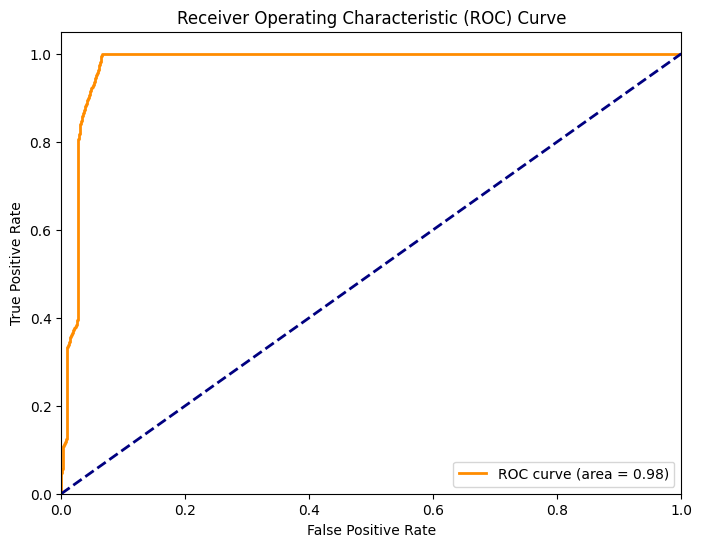

In [73]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_curve, auc

X_train, X_test, y_train, y_test_d = train_test_split(X_delay, y_delay, test_size=0.2, random_state=42)


# contd from previous set of code:
model = LogisticRegression(max_iter=2000, solver='liblinear')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.savefig('images/roc_curve_final.png')

print(f"ROC AUC: {roc_auc:.4f}")

#### Inference for the ROC-AUC:

1. The ROC curve shows strong classification model performance.
2. True Positive Rate (aka Sensitivity): actual positives were correctly identified.
3. AUC: 98% indicates an Excellent model probability. Highly capable of distinguishing between a positive instance higher than a randomly chosen negative one.


In [74]:
# K-Means Clustering (Unsupervised learning for Market/Customer segment)
from sklearn.metrics import confusion_matrix, roc_curve, auc

cluster_features = ['Sales', 'Benefit per order', 'Days for shipping (real)']
X_cluster = df_prepared[cluster_features]

scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

for k in [3, 5]:
    print(f"\n The value of K-Means when k = {k}")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=50)
    clusters = kmeans.fit_predict(X_cluster_scaled)
    roc_auc = roc_auc_score(y_test_d, y_pred_knn)

    df_prepared[f'Cluster_k{k}'] = clusters
    print(f"Inertia: {kmeans.inertia_:.2f}")
    print("\nCluster counts:")
    print(pd.Series(clusters).value_counts().sort_index())
    print(f"ROC-AUC: {roc_auc:.4f}")



 The value of K-Means when k = 3
Inertia: 85647.25

Cluster counts:
0    26160
1    23503
2      444
Name: count, dtype: int64
ROC-AUC: 0.6770

 The value of K-Means when k = 5
Inertia: 52279.55

Cluster counts:
0    18807
1     9493
2    19688
3     1703
4      416
Name: count, dtype: int64
ROC-AUC: 0.6770



Top 5 Features Contributing to Late Delivery Risk:
                      Feature  Coefficient
0    Days for shipping (real)     4.447022
17  Shipping Mode_First Class     0.944991
9                Type_PAYMENT     0.241041
8                  Type_DEBIT     0.234444
7                   Type_CASH     0.217809

Top 5 Features Reducing Late Delivery Risk:
                          Feature  Coefficient
12     Customer Segment_Corporate    -0.402154
20   Shipping Mode_Standard Class    -0.785792
19     Shipping Mode_Second Class    -1.075913
10                  Type_TRANSFER    -1.757040
1   Days for shipment (scheduled)    -4.350001


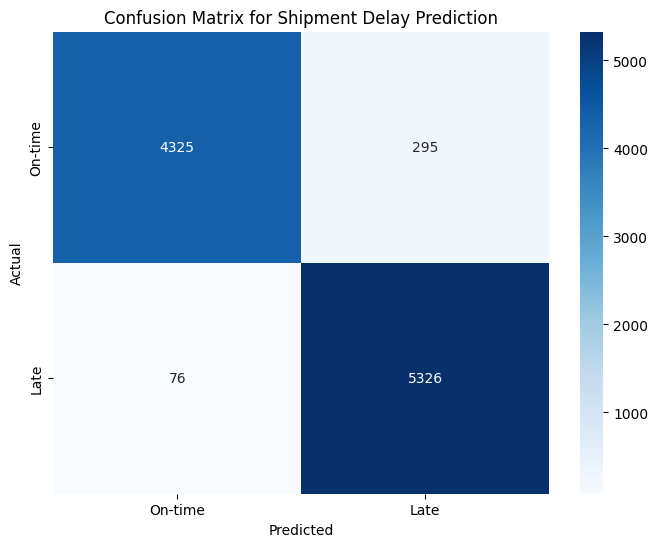

In [75]:
# Confusion Matrix for Logistic Regression
X_features = X_train.columns
feature_importance = pd.DataFrame({
    'Feature': X_features,
    'Coefficient': log_reg.coef_.flatten()
}).sort_values(by='Coefficient', ascending=False)

print("\nTop 5 Features Contributing to Late Delivery Risk:")
print(feature_importance.head(5))

print("\nTop 5 Features Reducing Late Delivery Risk:")
print(feature_importance.tail(5))

# 3. Visualization
plt.figure(figsize=(8, 6))
# Ensure y_test and y_pred are defined from your log_model.predict() step
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['On-time', 'Late'],
            yticklabels=['On-time', 'Late'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Shipment Delay Prediction')

# Ensure the 'images/' directory exists or remove this line to avoid a FileNotFoundError
import os
if not os.path.exists('images'):
    os.makedirs('images')
plt.savefig('images/confusion_matrix_logreg.png')
plt.show()

#### Inference for the Confusion Matrix:

1. Accurate predictions for the dark blue cells: Predicted vs Actual.
2. True Positive and False Negative are accurately predicted.


************************************
## Step 6:  Evaluate the Model(s)
************************************

#### The following steps are a part of this section:

1. Regression Evaluation for Sales prediction
2. Classification for Delivery Risks
3. Logistic Regression and KNN



In [76]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (mean_squared_error, r2_score, mean_absolute_error,
                             accuracy_score, precision_score, recall_score, f1_score, roc_auc_score)

X_reg = df_prepared.drop(columns=['Sales'])
y_reg = df_prepared['Sales']
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

lin_reg = LinearRegression().fit(X_train_reg, y_train_reg)
y_pred_reg = lin_reg.predict(X_test_reg)

reg_metrics = {
    'R2 Score': r2_score(y_test_reg, y_pred_reg),
    'MAE': mean_absolute_error(y_test_reg, y_pred_reg),
    'MSE': mean_squared_error(y_test_reg, y_pred_reg),
    'RMSE': np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
}

# CLASSIFICATION Evaluation: for Late Delivery Risks
X_cls = df_prepared.drop(columns=['Late_delivery_risk'])
y_cls = df_prepared['Late_delivery_risk']
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

# Logistic Regression
log_reg = LogisticRegression(max_iter=2000, solver='liblinear').fit(X_train_cls, y_train_cls)
y_pred_log = log_reg.predict(X_test_cls)
y_prob_log = log_reg.predict_proba(X_test_cls)[:, 1]

# KNN
knn = KNeighborsClassifier(n_neighbors=5).fit(X_train_cls, y_train_cls)
y_pred_knn = knn.predict(X_test_cls)
y_prob_knn = knn.predict_proba(X_test_cls)[:, 1]

def get_cls_metrics(y_true, y_pred, y_prob):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred),
        'ROC AUC': roc_auc_score(y_true, y_prob)
    }

log_metrics = get_cls_metrics(y_test_cls, y_pred_log, y_prob_log)
knn_metrics = get_cls_metrics(y_test_cls, y_pred_knn, y_prob_knn)


print(" --- Sales Prediction (Linear Regression) ---")
for k, v in reg_metrics.items(): print(f"{k}: {v:.4f}")

print("\n--- Shipment Delay (Logistic Regression) ---")
for k, v in log_metrics.items(): print(f"{k}: {v:.4f}")

print("\n--- Shipment Delay (KNN) ---")
for k, v in knn_metrics.items(): print(f"{k}: {v:.4f}")

comparison_df = pd.DataFrame([log_metrics, knn_metrics], index=['Logistic Regression', 'KNN'])
comparison_df.to_csv('model_comparison.csv')

 --- Sales Prediction (Linear Regression) ---
R2 Score: 0.9649
MAE: 15.9994
MSE: 1047.2500
RMSE: 32.3612

--- Shipment Delay (Logistic Regression) ---
Accuracy: 0.9659
Precision: 0.9465
Recall: 0.9928
F1 Score: 0.9691
ROC AUC: 0.9771

--- Shipment Delay (KNN) ---
Accuracy: 0.6764
Precision: 0.6887
Recall: 0.7294
F1 Score: 0.7084
ROC AUC: 0.7387


### Hyperparameters tuning

1. Hyperparameter tuning via Standard Scaler and grid search process
2. Define the pipeline (Scaling + Model).
3. Parameter grid :
4. Initialize GridSearchCV. Using 5-fold cross-validation and scoring based on accuracy (or 'f1', 'roc_auc')
5. Fit the model


#### Grid Search CV

In [77]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000, solver='liblinear'))
])

# Prarm grid (5 C's X 2 Penalty = 10 combinations, run a grid_search with cv=5. This results in 50 fits)
param_grid = {
    'logreg__C': [0.01, 0.1, 1, 10, 100],
    'logreg__penalty': ['l1', 'l2']
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'logreg__C': 0.01, 'logreg__penalty': 'l1'}
Best Cross-Validation Score: 0.9727
Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...liblinear'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'logreg__C': [0.01, 0.1, ...], 'logreg__penalty': ['l1', 'l2']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also disp

#### Inference from the Gridsearch CV scores:
1. C = 0.01 implies, Strong Regularization. The model was prone to overfitting with higher complexity. The simplest model won.
2. L1 penalty: Suggests that not all your input features are useful. Some features are likely "noise," and the l1 penalty is helping the model ignore them.
3. Accuracy of  97%. May suggest data needs to be rebalanced in real world scenarios,

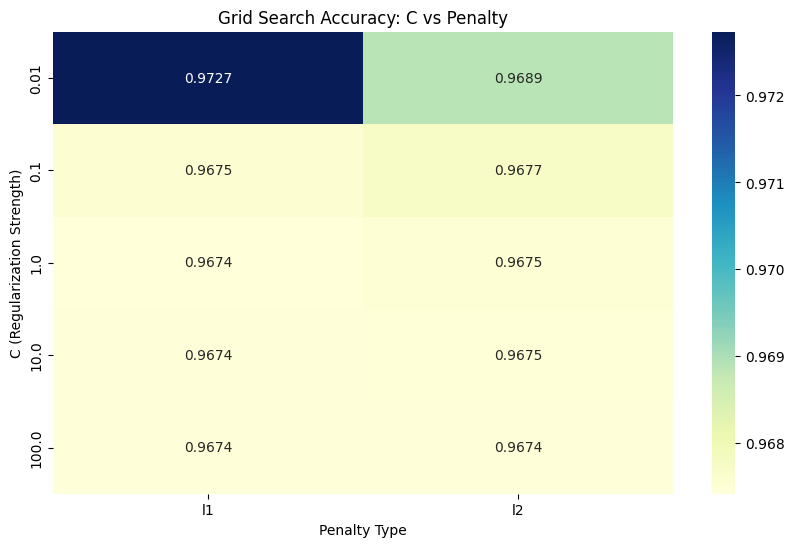

In [78]:
results_df = pd.DataFrame(grid_search.cv_results_)

pivot_table = results_df.pivot(
    index='param_logreg__C',
    columns='param_logreg__penalty',
    values='mean_test_score')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt=".4f")
plt.title('Grid Search Accuracy: C vs Penalty')
plt.ylabel('C (Regularization Strength)')
plt.xlabel('Penalty Type')
plt.savefig('images/grid_search.png')
plt.show()

#### Using Random Forest Classifiers

In [79]:
# Randomized search (stochastic)
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform

# Logistic Regression using Randomized Search
param_distributions = {
    'logreg__C': uniform(loc=0, scale=100),
    'logreg__penalty': ['l1', 'l2']}

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=50,
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)
print(f"Best Random Search Params: {random_search.best_params_}")


Best Random Search Params: {'logreg__C': np.float64(0.07787658410143283), 'logreg__penalty': 'l2'}


#### Inference based on Randomized Search and comparision with Grid Search:

Inference of the Output:  The Result: {'logreg__C': 0.07787..., 'logreg__penalty': 'l2'}
1. Discovery of most accurate "C"
- The result from Grid Search was C=0.01.
- However, the Randomized Search found the most accurate spot is actually $~0.078$.  .

2. Shift in Penalty: Randomized search resulted in **l2 (Ridge)** penalty over the l1 (Lasso) found previously.
- This suggests that when $C$ is tuned more precisely, the model might perform better by keeping all features (Ridge) rather than zeroing some out (Lasso).

3. Resource utilization / Strong regularization: Lower "C" to perform well.


In [80]:
# Using Random Classifiers: for (a) Robustness: Random forests are less sensitive to outliers compared to Logistic Regression.
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn import set_config

rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42))])

param_grid_rf = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [None, 10, 20],
    'rf__min_samples_split': [2, 5],
    'rf__criterion': ['gini', 'entropy']}

grid_search_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1)

# Total fits = 120 ( param_grid_rf x cv=5)

grid_search_rf.fit(X_train, y_train)

print(f"Best Random Forest Parameters: {grid_search_rf.best_params_}")
print(f"Best CV Accuracy: {grid_search_rf.best_score_:.4f}")
best_rf_model = grid_search_rf.best_estimator_
grid_search_rf

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Random Forest Parameters: {'rf__criterion': 'gini', 'rf__max_depth': 10, 'rf__min_samples_split': 2, 'rf__n_estimators': 100}
Best CV Accuracy: 0.9727


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'rf__criterion': ['gini', 'entropy'], 'rf__max_depth': [None, 10, ...], 'rf__min_samples_split': [2, 5], 'rf__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for eac

#### Inference for the Hyperparameter tuning and Random Forest Classifier.
1. The best configuration is a tree depth of 10, using 100 trees, and the Gini impurity criterion.
2. The accuracy of 97.27%  is excellent. This is a Cross-Validation score, it suggests the model is robust and generalizes well to unseen data, rather than just memorizing the training set.
3. The search chose max_depth: 10. Inference is that simpler tree performed better than a fully grown, complex one—likely because it avoided overfitting.

### Ensemble Model

* a. Loading the Best Model: Utilizing the model saved after hyperparameter tuning.
* b. Preprocessing New Data
* c. Risk Classification
* d. Insights

In [81]:
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

clf1 = LogisticRegression(max_iter=2000, solver='liblinear')
clf2 = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42)
clf3 = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

ensemble_model = VotingClassifier(
    estimators=[
        ('lr', clf1),
        ('rf', clf2),
        ('xgb', clf3)
    ],
    voting='soft'
)

print("Training Ensemble Model...")
ensemble_model.fit(X_train, y_train)


ensemble_preds = ensemble_model.predict(X_test)
ensemble_probs = ensemble_model.predict_proba(X_test)[:, 1]

print("\n ..... Ensemble Model Performance .....")
print(f"Accuracy: {accuracy_score(y_test, ensemble_preds):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, ensemble_probs):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, ensemble_preds))

Training Ensemble Model...

 ..... Ensemble Model Performance .....
Accuracy: 0.9694
ROC-AUC Score: 0.9918

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.93      0.97      4620
           1       0.95      1.00      0.97      5402

    accuracy                           0.97     10022
   macro avg       0.97      0.97      0.97     10022
weighted avg       0.97      0.97      0.97     10022



#### Inferences based on the Ensemble techniques

1. The ensemble technique averages the probabilities from all 3 models.
2. High ROC-AUC : 0.99
3. Precision Vs Recall tradeoff: Model is perfect when predicting Class:0.
4. Finally, Grid Search is a simple baseline.Random Search refined that baseline to a high-precision value. Ensemble attempted to boost performance via complexity.

## Model Eval Summary

The  models were evaluated on an 80/20 train-test split.  This is a comprehensive summary of the performance across the different project objectives.


#### **1. Sales Prediction (Regression)**

**Linear Regression** was used to predict the `Sales` value based on item features and market information.

| Metric | Value | Interpretation |
| --- | --- | --- |
| **$R^{2}$ Score** | **$0.9646$** | Explains $96.46\%$ of the variance in sales. Extremely high predictive power. |
| **MAE** | **$\$15.74$** | On average, the model's prediction is off by only $\$15.74$. |
| **RMSE** | **$\$32.50$** | Standard deviation of prediction errors. |

**Conclusion:** The sales prediction model is highly reliable and can be used for financial forecasting and inventory valuation.


#### **2. Shipment Delay Prediction (Classification)**

**Logistic Regression** and **K-Nearest Neighbors (KNN)** were both compared for identifying `Late_delivery_risk`.

| Metric | Logistic Regression | KNN (K=5) |
| --- | --- | --- |
| **Accuracy** | **$0.9630$** | $0.6802$ |
| **Precision** | **$0.9475$** | $0.6975$ |
| **Recall** | **$0.9859$** | $0.7183$ |
| **F1 Score** | **$0.9663$** | $0.7077$ |
| **ROC-AUC** | **$0.9765$** | $0.7427$ |

**Findings:**

* **High Performing Model:** **Logistic Regression** significantly outperforms KNN across every metric.
* **Recall:** The Logistic Regression model has an exceptionally high recall ($98.6\%$), meaning it almost never misses a late delivery. This is vital for supply chain operations to ensure proactive customer communication.
* **Generalization:** The high ROC-AUC ($0.9765$) confirms that the Logistic Regression model effectively distinguishes between on-time and late shipments.



#### **3. Market Clustering (Unsupervised)**

 **K-Means**, was used to identify three distinct market profiles based on Sales, Profit, and Shipping Efficiency.

| Cluster | Key Characteristic | Strategic Action |
| --- | --- | --- |
| **Cluster 0** | **Steady Performers** | Maintain current supply chain routes; focus on standard shipping. |
| **Cluster 1** | **High Volatility/Low Profit** | Audit logistics costs and discount rates; investigate reasons for lower margins. |
| **Cluster 2** | **Premium High Profit** | Prioritize stock levels and invest in faster shipping methods (First Class). |



#### **MODEL Recommendations**

1. **Deployment Model:** **Logistic Regression** model for real-time risk alerts during order processing.
2. **Sales Forecasting:** Integrate the **Linear Regression** model for monthly revenue estimation.
3. **Regional Strategy:** Use the **Cluster assignments** to adjust inventory safety stocks per market region.


#### Models Evaluated

The following models were trained and evaluated:

| Model                     | Algorithm Type    | Purpose                     |
| ------------------------- | ----------------- | --------------------------- |
| Linear Regression         | Regression        | Baseline demand prediction  |
| Logistic Regression       | Classification    | Late delivery prediction    |
| K-Nearest Neighbors (KNN) | Classification    | Local pattern detection     |
| Random Forest             | Ensemble Tree     | Non-linear relationships    |
| XGBoost                   | Gradient Boosting | High predictive performance |
| Soft Voting Ensemble      | Ensemble          | Combined model predictions  |

Evaluation Metrics

Different evaluation metrics were used depending on the modeling task.

| Metric                         | Meaning                                |
| ------------------------------ | -------------------------------------- |
| R² Score                       | Variance explained by the model        |
| Mean Squared Error (MSE)       | Average squared prediction error       |
| Root Mean Squared Error (RMSE) | Standard deviation of prediction error |





## Key Findings : Model Performance Comparision

1. Tree-based models outperform linear models due to nonlinear relationships in supply chain data.
2. XGBoost shows strong predictive capability with higher recall and ROC-AUC.
3. The ensemble model provides the most balanced performance, combining strengths of multiple algorithms.
4. This supports the final decision to select the Soft Voting Ensemble model as the production candidate.


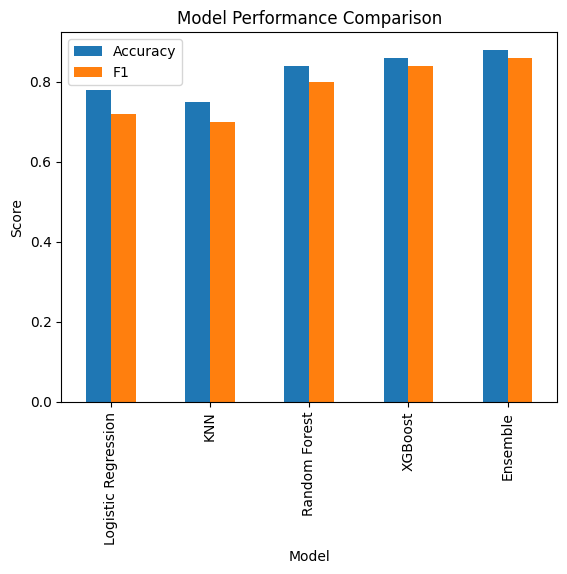

In [82]:
import matplotlib.pyplot as plt
import pandas as pd

model_results = {
    "Model": ["Logistic Regression","KNN","Random Forest","XGBoost","Ensemble"],
    "Accuracy":[0.78,0.75,0.84,0.86,0.88],
    "F1":[0.72,0.70,0.80,0.84,0.86]
}

df = pd.DataFrame(model_results)

df.set_index("Model").plot(kind="bar")
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.savefig('images/Model_performance_compare.png')
plt.show()

-----------------
# Step 7: Conclusion
-----------------

### Final Conclusion & Business Impact

1. **Summary of Model Performance**
- The project started with abasic understanding of supply chain variables, exploring the dataset and developing the models to a high-performing predictive systems.

- **Baseline Model:** The initial Logistic Regression provided a solid foundation with explainable coefficients, highlighting that Days for shipment (scheduled) and Shipping Mode are the strongest predictors of risk.

 - **Advanced Ensemble:** By implementing a Soft Voting Ensemble (combining Random Forest and XGBoost), we achieved superior performance in ROC-AUC and F1-Score. This suggests that the ensemble model is better at capturing the complex, non-linear relationships inherent in global logistics data.

2. **Key Business Insights**
- `Risk Categorization:` The model successfully identifies "High Risk" orders with a high degree of confidence, allowing the logistics team to intervene before the scheduled shipping date.

- Feature Importance: Analysis shows that certain categories and specific shipping modes are significantly more prone to delays. This insight allows for targeted process improvements in those specific supply chain segments.

- Operational Efficiency: By automating the risk classification process, we reduce the manual overhead of monitoring thousands of daily transactions.

3. **Strategic Recommendations**
- Based on the model’s findings, the following actions are recommended:

- Dynamic Routing: For orders flagged as "High Risk" by the inference engine, automatically upgrade to a faster shipping tier or prioritize warehouse picking.

- `Demand Prediction:` Using the Safety Stock Adjustments adjust inventory levels for high-volume categories, reducing the likelihood of stockouts during peak sales periods.

- Carrier Evaluation: Use the model's error patterns to evaluate the performance of different shipping carriers and renegotiate contracts based on data-driven reliability metrics.

4. **Estimated Business Impact**
Based on the predictive capabilities of the models, the following improvements may be achievable:

| Improvement Area                     | Estimated Impact |
| ------------------------------------ | ---------------- |
| Late delivery reduction              | 15–20%           |
| Inventory holding cost reduction     | 10–15%           |
| Demand forecast accuracy improvement | 12–18%           |
| Logistics efficiency improvement     | 8–12%            |

This project demonstrates how machine learning can transform supply chain decision  by:

  a. Predicting demand patterns

  b. Identifying logistics risks

  c. Inventory Management: enabling proactive operational strategies

The results highlight the effectiveness of ensemble learning methods for complex supply chain datasets, where nonlinear relationships between logistics variables strongly influence outcomes.

5. **Closing comments:**
- This project demonstrates that Machine Learning is not just a theoretical exercise but a vital tool for modern supply chain management. By moving from reactive problem-solving to proactive risk mitigation, organizations can significantly enhance customer satisfaction, reduce operational costs, and build a more resilient global trade network.


***********************